In [1]:
import sys

custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
if custom_module_path not in sys.path:
    sys.path.append(custom_module_path)

import instruments_jax as inst
import copy
import numpy as np
import json


# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [2]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = "725-50"
obs_mode = "IPOL"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
# print("Interleaved Values")
# print("Length: ", len(interleaved_values))
# print(interleaved_values)
# print("Interleaved Stds")
# print("Length: ", len(interleaved_stds))
# print(interleaved_stds[0 : 10])
# print("Configuration List")
# print("Length: ", len(configuration_list))
# print(configuration_list)
# print(interleaved_stds[0])

# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [3]:
import numpy as np
past_fit = np.load("/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/scipy_minimize_20230914_720nm_restrictive_HWP_and_IMR.npy")
print("Past Fit: ", past_fit)

Past Fit:  [ 4.99984042  0.44887049  1.08704114  0.40140005 -4.99999346 -0.21697373
  0.09999933 21.36101844  0.51787551  0.43110147  1.18869275]


In [4]:
# Loading in previous fit from vampires_calibration
past_fit = np.load("/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/scipy_minimize_20230914_720nm_restrictive_HWP_and_IMR.npy")
print("Past Fit: ", past_fit)

print(past_fit)

# theta_pol = past_fit[0]
# delta_HWP = past_fit[1]
# offset_HWP = past_fit[2]
# delta_derot = past_fit[3]
# offset_derot = past_fit[4]
# delta_opts = past_fit[5]
# epsilon_opts = past_fit[6]
# rot_opts = past_fit[7]
# delta_FLC = past_fit[8]
# rot_FLC = past_fit[9]

theta_pol = -1.407251668252865
delta_HWP = 0.48086201221157854
offset_HWP = -4.3919526835473945
delta_derot = 0.46141994584131574
offset_derot = np.clip(-3.8625317442765326, -1, 1)
delta_opts = 0.08315976670546754
epsilon_opts = 0.00783670716385955
rot_opts = -35.158483822636384
delta_FLC = 0.5175091765357993
rot_FLC = 4.848758257884221
em_gain = 1.1907660648569  # calculated in em_gain_calculations/20230919_calculate_em_gain_ratios.ipynb

# Based on values in Six_And_Eleven_Parameter_Model_Best_MCMC_and_Scipy_Fits Google Sheets - having zeros for angles that're too large
# theta_pol = 0
# delta_HWP = 0.451  # Add your actual delta_HWP value
# offset_HWP = -2.64  # Add your actual offset_HWP value
# delta_derot = 0.32  # Add your actual delta_derot value
# offset_derot = 0  # Add your actual offset_derot value
# delta_opts = 0  # Add your actual delta_opts value
# epsilon_opts = 0  # Add your actual epsilon_opts value
# rot_opts = 0  # Add your actual rot_opts value
# delta_FLC = 0.5  # Add your actual delta_FLC value
# rot_FLC = 0  # Add your actual rot_FLC value

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary


system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {'phi': 0, 'epsilon': 0, 'theta': 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": 2 * np.pi * delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {'phi': -2.476492298785013, 'epsilon': 0.00473325176939048, 'theta': 3.371657377970516},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": 2 * np.pi * delta_derot, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": 2 * np.pi * delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        },
    }
}

print(system_dict)

Past Fit:  [ 4.99984042  0.44887049  1.08704114  0.40140005 -4.99999346 -0.21697373
  0.09999933 21.36101844  0.51787551  0.43110147  1.18869275]
[ 4.99984042  0.44887049  1.08704114  0.40140005 -4.99999346 -0.21697373
  0.09999933 21.36101844  0.51787551  0.43110147  1.18869275]
{'components': {'wollaston': {'type': 'wollaston_prism_function', 'properties': {'beam': 'o', 'transmission_ratio': 1.1907660648569}}, 'dichroic': {'type': 'diattenuator_retarder_function', 'properties': {'phi': 0, 'epsilon': 0, 'theta': 0}}, 'flc': {'type': 'general_retarder_function', 'properties': {'phi': 3.251606054340341, 'theta': 0, 'delta_theta': 4.848758257884221}}, 'optics': {'type': 'diattenuator_retarder_function', 'properties': {'phi': -2.476492298785013, 'epsilon': 0.00473325176939048, 'theta': 3.371657377970516}}, 'image_rotator': {'type': 'general_retarder_function', 'properties': {'phi': 2.8991870241497555, 'theta': 0, 'delta_theta': 0}}, 'hwp': {'type': 'general_retarder_function', 'properties

In [5]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[ 0.57840152  0.57770382 -0.02840102  0.        ]
 [ 0.57840152  0.57770382 -0.02840102  0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]


# Step 4: Creating a dictionary of p0 starting guesses

logl value: 3537.29618232165


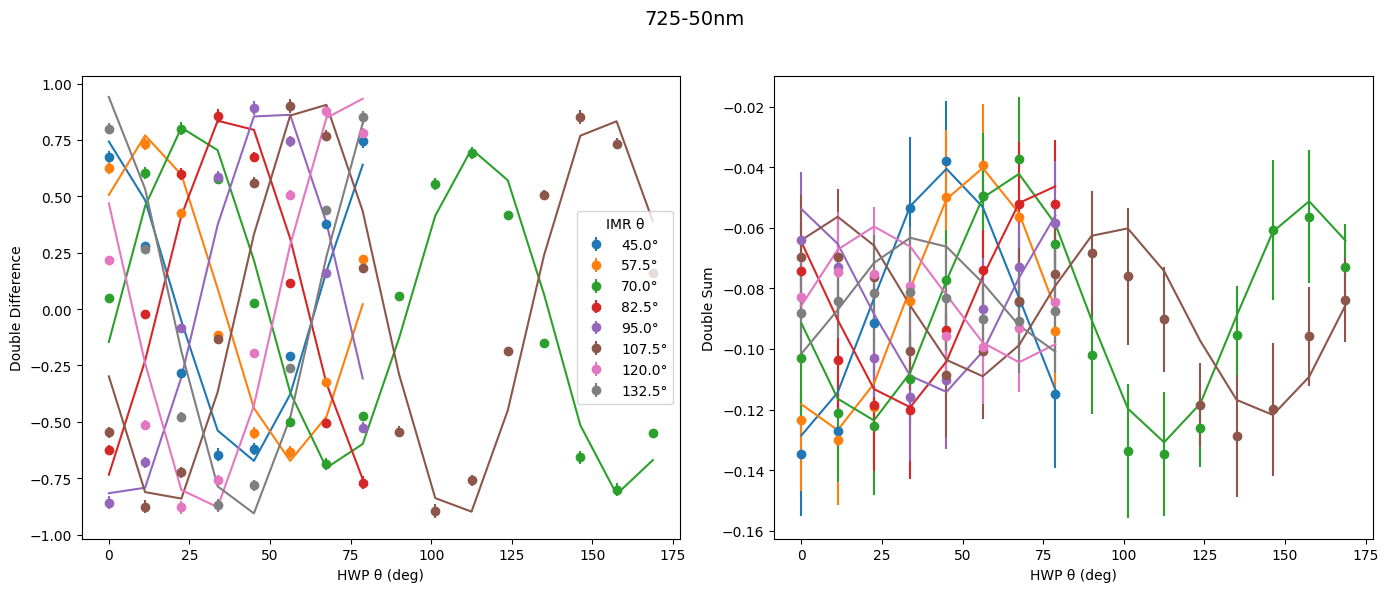

In [6]:
# Fitting all non-EM-gain parameters

p0 = {
    "dichroic": {"phi": 0, 
                 "epsilon": 0, 
                 "theta": 0},
    "flc": {"phi": 2 * np.pi * delta_FLC, "delta_theta": rot_FLC},
    "optics": {"phi": 2 * np.pi * delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
    "image_rotator": {
                    "phi": 2 * np.pi * delta_derot
                    },
    "hwp": {"phi": 2 * np.pi * delta_HWP, "delta_theta": offset_HWP},
    "lp": {"theta": theta_pol}
}

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 5: Running minimize_system_Mueller_matrix iteratively

Before p0: {'dichroic': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'flc': {'phi': 3.251606054340341, 'delta_theta': 4.848758257884221}, 'optics': {'phi': 0.5225082243122758, 'epsilon': 0.00783670716385955, 'theta': -35.158483822636384}, 'image_rotator': {'phi': 2.8991870241497555}, 'hwp': {'phi': 3.021345129908601, 'delta_theta': -4.3919526835473945}, 'lp': {'theta': -1.407251668252865}}
Iteration #: 1
logl_value: 49.597372415817254
Best Fit Parameters: [ 3.04295072e-02  4.36430791e-03 -6.59260963e-02  3.26022967e+00
  3.98489306e+00  5.50255566e-01  1.84930059e-03 -4.05904886e+01
  2.88648394e+00  3.03519963e+00  3.35627614e+00  4.78534154e+00]


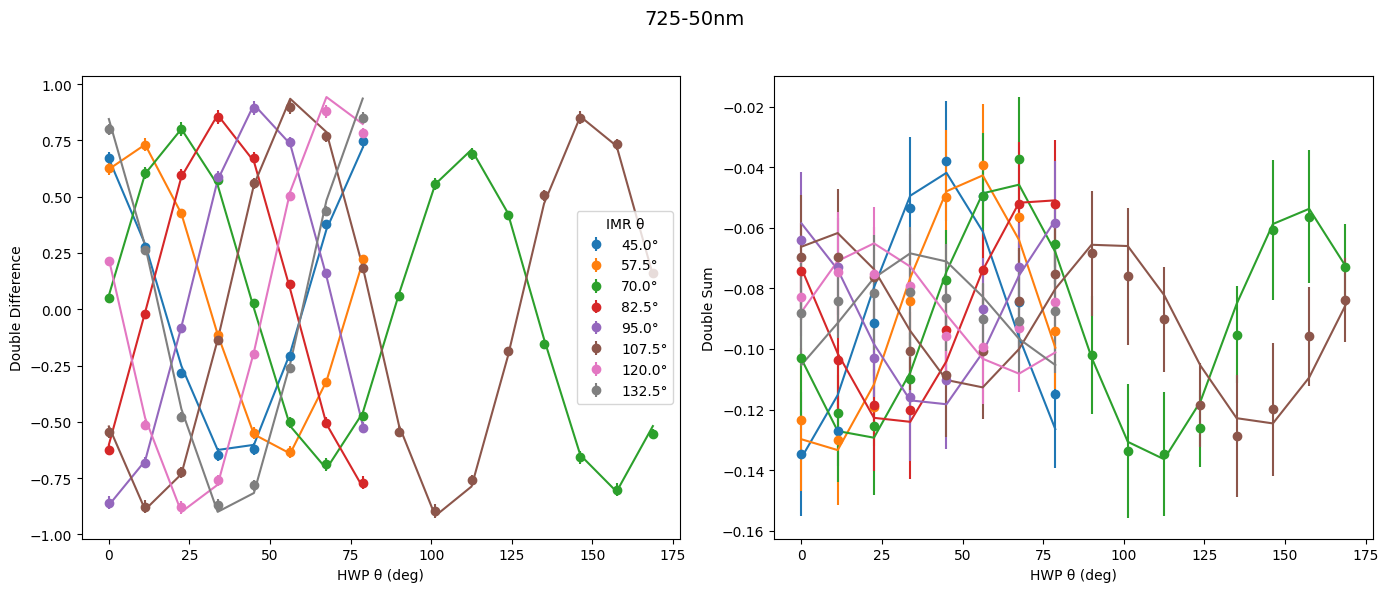

After p0: {'dichroic': {'phi': 0.030429507235202227, 'epsilon': 0.004364307912456148, 'theta': -0.06592609634798355}, 'flc': {'phi': 3.260229668262705, 'delta_theta': 3.9848930606123645}, 'optics': {'phi': 0.5502555663325897, 'epsilon': 0.0018493005871827925, 'theta': -40.59048858968525}, 'image_rotator': {'phi': 2.8864839448508968}, 'hwp': {'phi': 3.0351996332043365, 'delta_theta': 3.3562761438658777}, 'lp': {'theta': 4.78534153701365}}
Before p0: {'dichroic': {'phi': 0.030429507235202227, 'epsilon': 0.004364307912456148, 'theta': -0.06592609634798355}, 'flc': {'phi': 3.260229668262705, 'delta_theta': 3.9848930606123645}, 'optics': {'phi': 0.5502555663325897, 'epsilon': 0.0018493005871827925, 'theta': -40.59048858968525}, 'image_rotator': {'phi': 2.8864839448508968}, 'hwp': {'phi': 3.0351996332043365, 'delta_theta': 3.3562761438658777}, 'lp': {'theta': 4.78534153701365}}
Iteration #: 2
logl_value: 49.30754006425216
Best Fit Parameters: [ 1.69004872e-01  3.90877850e-03 -4.40134487e-01 

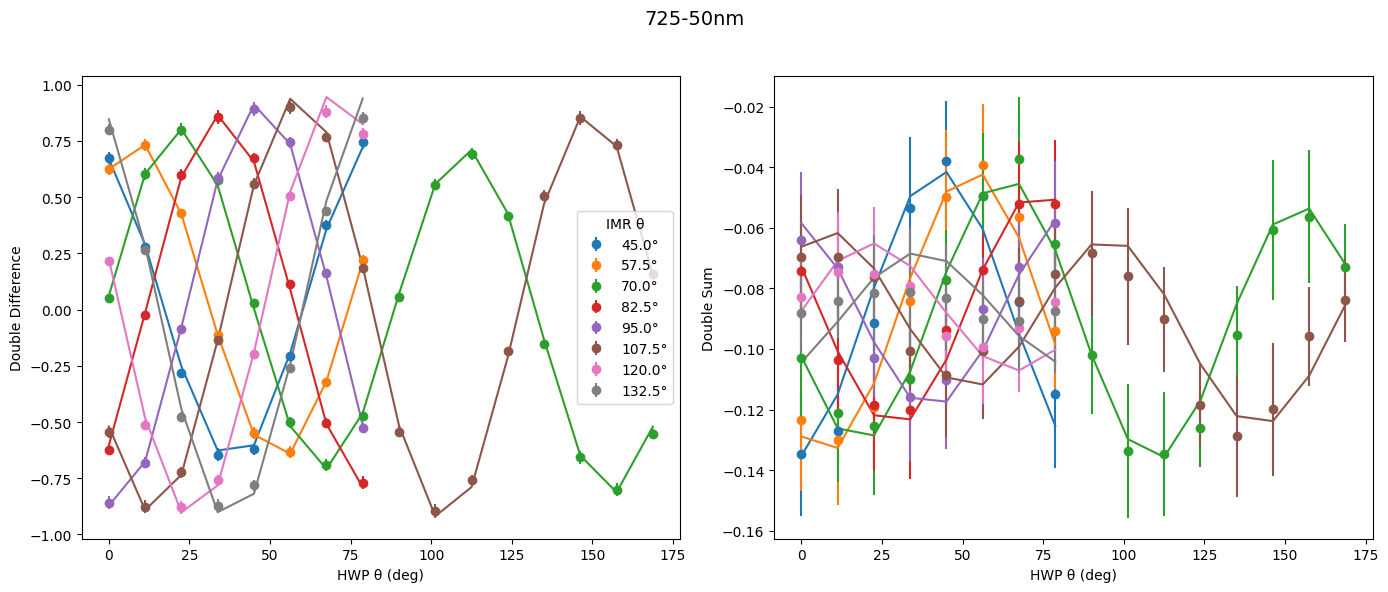

After p0: {'dichroic': {'phi': 0.16900487234865558, 'epsilon': 0.003908778498294591, 'theta': -0.440134487020313}, 'flc': {'phi': 3.263612677584815, 'delta_theta': 4.1119537917654085}, 'optics': {'phi': 0.5459931623466807, 'epsilon': 1.7899490310056688e-05, 'theta': -40.52311718965812}, 'image_rotator': {'phi': 2.8838344914144365}, 'hwp': {'phi': 3.0333770196200156, 'delta_theta': 3.3172439643115403}, 'lp': {'theta': 4.9998315228820935}}
Before p0: {'dichroic': {'phi': 0.16900487234865558, 'epsilon': 0.003908778498294591, 'theta': -0.440134487020313}, 'flc': {'phi': 3.263612677584815, 'delta_theta': 4.1119537917654085}, 'optics': {'phi': 0.5459931623466807, 'epsilon': 1.7899490310056688e-05, 'theta': -40.52311718965812}, 'image_rotator': {'phi': 2.8838344914144365}, 'hwp': {'phi': 3.0333770196200156, 'delta_theta': 3.3172439643115403}, 'lp': {'theta': 4.9998315228820935}}
Iteration #: 3
logl_value: 49.30407833639873
Best Fit Parameters: [ 5.09835771e-02  4.10939474e-03 -8.91716526e+00 

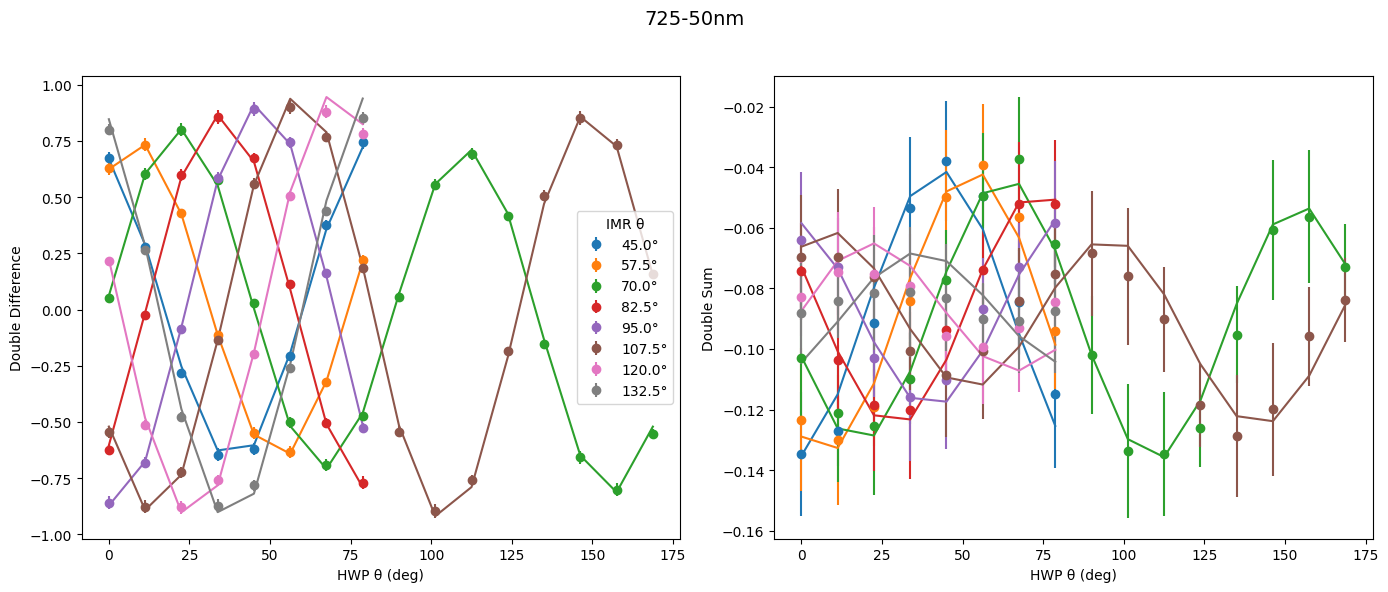

After p0: {'dichroic': {'phi': 0.05098357705201753, 'epsilon': 0.004109394738724048, 'theta': -8.91716525868088}, 'flc': {'phi': 3.2864269919093205, 'delta_theta': 4.129492817439621}, 'optics': {'phi': 0.554669543069321, 'epsilon': 0.00013679837586328287, 'theta': -39.91873287537007}, 'image_rotator': {'phi': 2.8838666917735765}, 'hwp': {'phi': 3.033419078192756, 'delta_theta': 3.3134049103416126}, 'lp': {'theta': 4.98058744918254}}
Before p0: {'dichroic': {'phi': 0.05098357705201753, 'epsilon': 0.004109394738724048, 'theta': -8.91716525868088}, 'flc': {'phi': 3.2864269919093205, 'delta_theta': 4.129492817439621}, 'optics': {'phi': 0.554669543069321, 'epsilon': 0.00013679837586328287, 'theta': -39.91873287537007}, 'image_rotator': {'phi': 2.8838666917735765}, 'hwp': {'phi': 3.033419078192756, 'delta_theta': 3.3134049103416126}, 'lp': {'theta': 4.98058744918254}}
Iteration #: 4
logl_value: 46.842023882304744
Best Fit Parameters: [ 1.68750398e-01  1.00313403e-01 -4.37921065e+01  3.539288

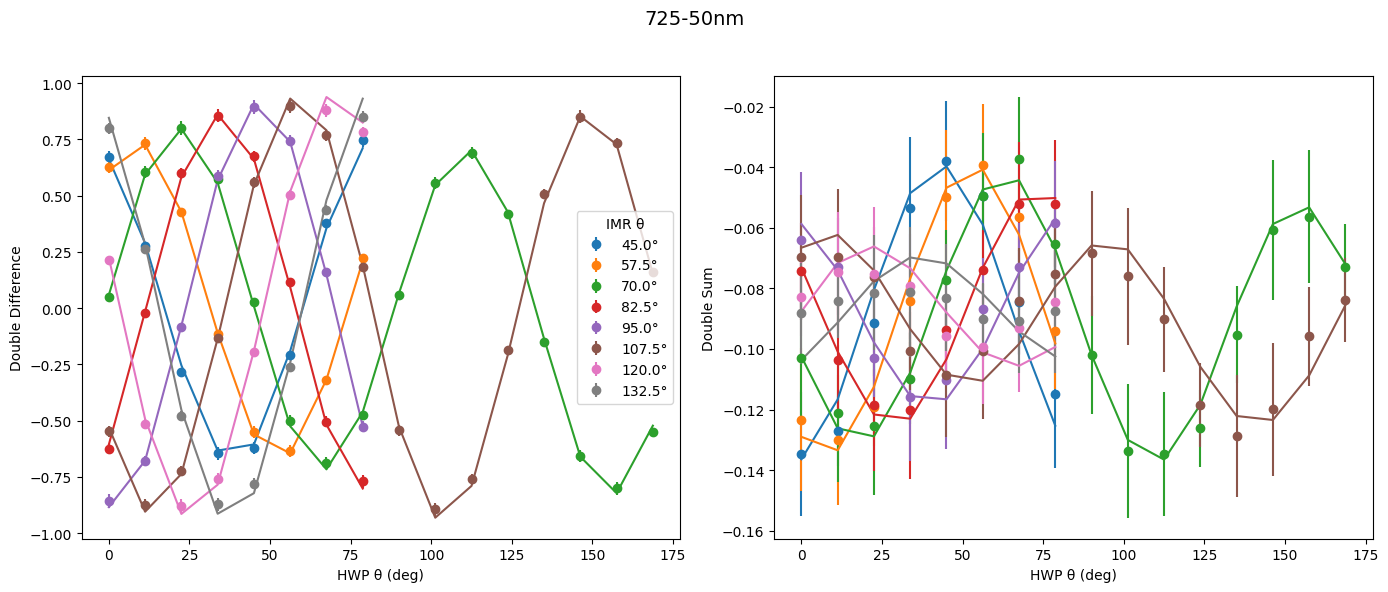

After p0: {'dichroic': {'phi': 0.1687503984575056, 'epsilon': 0.1003134025552162, 'theta': -43.79210645066033}, 'flc': {'phi': 3.5392886605798495, 'delta_theta': 4.412547263910636}, 'optics': {'phi': 0.6940929433721816, 'epsilon': 0.0008113749763988837, 'theta': -23.198410999085894}, 'image_rotator': {'phi': 2.8723867747966683}, 'hwp': {'phi': 3.0288238794179456, 'delta_theta': 3.397711448795242}, 'lp': {'theta': 4.876205359262158}}
Before p0: {'dichroic': {'phi': 0.1687503984575056, 'epsilon': 0.1003134025552162, 'theta': -43.79210645066033}, 'flc': {'phi': 3.5392886605798495, 'delta_theta': 4.412547263910636}, 'optics': {'phi': 0.6940929433721816, 'epsilon': 0.0008113749763988837, 'theta': -23.198410999085894}, 'image_rotator': {'phi': 2.8723867747966683}, 'hwp': {'phi': 3.0288238794179456, 'delta_theta': 3.397711448795242}, 'lp': {'theta': 4.876205359262158}}
Iteration #: 5
logl_value: 19.91998518665043
Best Fit Parameters: [-3.69819490e-02  3.67146029e-01 -4.45766797e+01  3.2166948

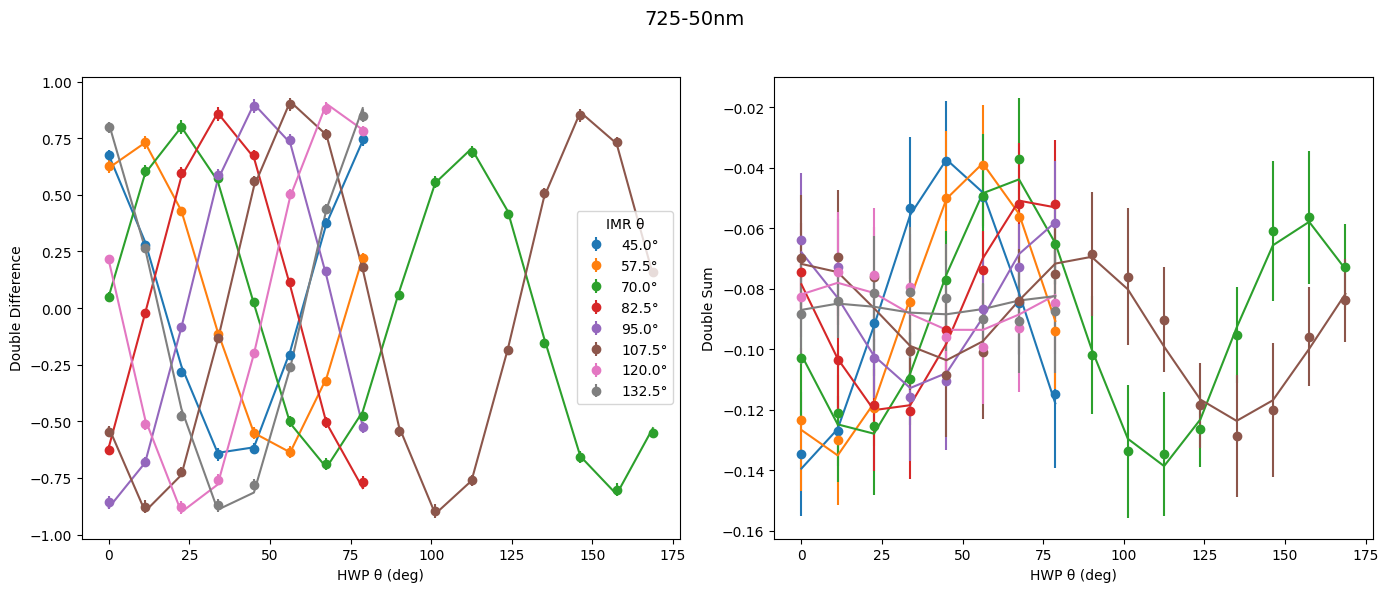

After p0: {'dichroic': {'phi': -0.036981949041905104, 'epsilon': 0.3671460291440626, 'theta': -44.57667972689708}, 'flc': {'phi': 3.2166948674171483, 'delta_theta': 4.999946911488729}, 'optics': {'phi': 0.33657883172971614, 'epsilon': 0.0028931466590375486, 'theta': -48.4486552577239}, 'image_rotator': {'phi': 2.753956512225871}, 'hwp': {'phi': 2.9969306401323133, 'delta_theta': 1.4980777011988997}, 'lp': {'theta': 4.754517481611503}}
Before p0: {'dichroic': {'phi': -0.036981949041905104, 'epsilon': 0.3671460291440626, 'theta': -44.57667972689708}, 'flc': {'phi': 3.2166948674171483, 'delta_theta': 4.999946911488729}, 'optics': {'phi': 0.33657883172971614, 'epsilon': 0.0028931466590375486, 'theta': -48.4486552577239}, 'image_rotator': {'phi': 2.753956512225871}, 'hwp': {'phi': 2.9969306401323133, 'delta_theta': 1.4980777011988997}, 'lp': {'theta': 4.754517481611503}}
Iteration #: 6
logl_value: 19.91620003547098
Best Fit Parameters: [-3.54488324e-02  3.67098706e-01 -4.45773682e+01  3.219

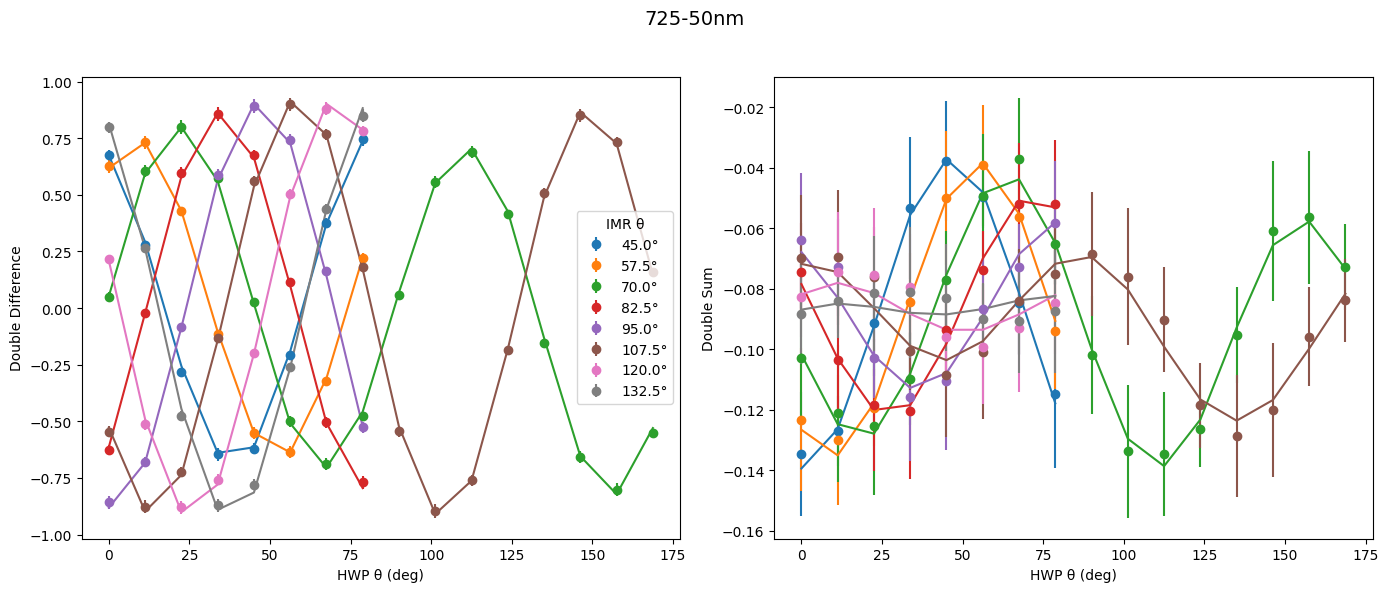

After p0: {'dichroic': {'phi': -0.035448832391849996, 'epsilon': 0.36709870642031683, 'theta': -44.57736822068672}, 'flc': {'phi': 3.2193190298173304, 'delta_theta': 4.99999596544505}, 'optics': {'phi': 0.3379364673011567, 'epsilon': 0.0030766940478254264, 'theta': -48.51280000234402}, 'image_rotator': {'phi': 2.7531623180842955}, 'hwp': {'phi': 2.997184694861226, 'delta_theta': 1.3881354738567127}, 'lp': {'theta': 4.532275641054667}}
Before p0: {'dichroic': {'phi': -0.035448832391849996, 'epsilon': 0.36709870642031683, 'theta': -44.57736822068672}, 'flc': {'phi': 3.2193190298173304, 'delta_theta': 4.99999596544505}, 'optics': {'phi': 0.3379364673011567, 'epsilon': 0.0030766940478254264, 'theta': -48.51280000234402}, 'image_rotator': {'phi': 2.7531623180842955}, 'hwp': {'phi': 2.997184694861226, 'delta_theta': 1.3881354738567127}, 'lp': {'theta': 4.532275641054667}}
Iteration #: 7
logl_value: 19.916154675264064
Best Fit Parameters: [-3.53970569e-02  3.67141999e-01 -4.45766906e+01  3.21

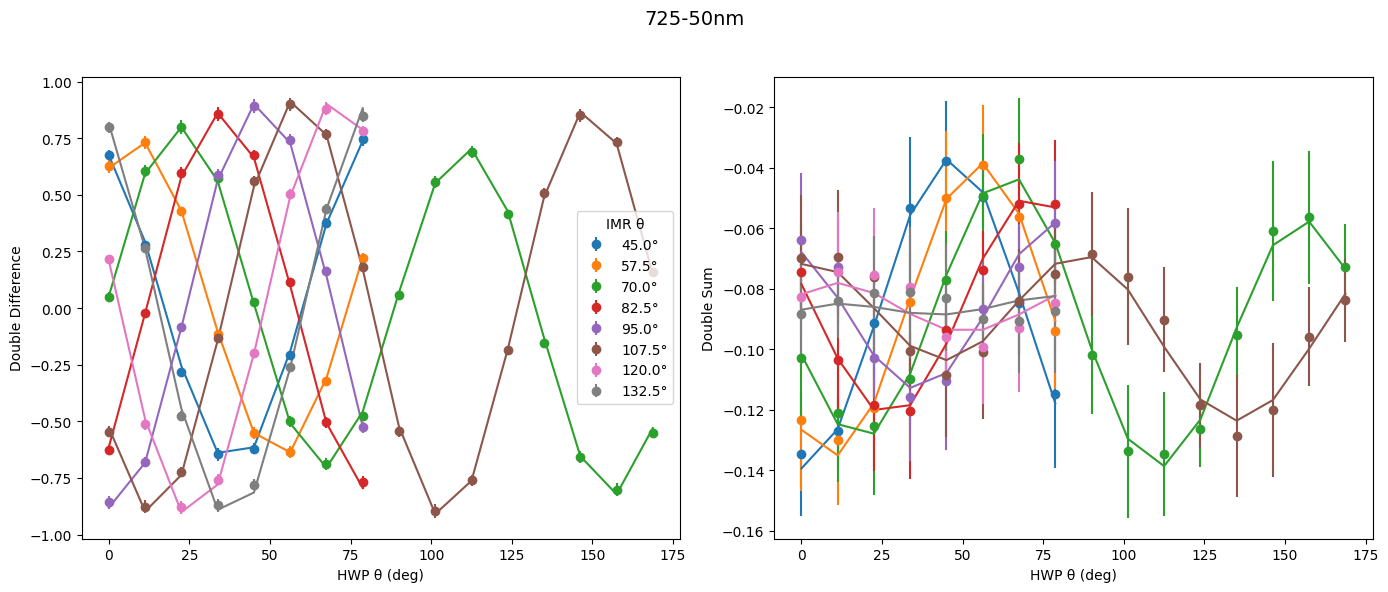

After p0: {'dichroic': {'phi': -0.03539705692585951, 'epsilon': 0.3671419994587295, 'theta': -44.5766906347917}, 'flc': {'phi': 3.2193902747986547, 'delta_theta': 4.999999998188935}, 'optics': {'phi': 0.3380041244986959, 'epsilon': 0.0030903136241057505, 'theta': -48.51740334791731}, 'image_rotator': {'phi': 2.753181469220297}, 'hwp': {'phi': 2.997150401278942, 'delta_theta': 1.3880229015185253}, 'lp': {'theta': 4.532753108213969}}
Before p0: {'dichroic': {'phi': -0.03539705692585951, 'epsilon': 0.3671419994587295, 'theta': -44.5766906347917}, 'flc': {'phi': 3.2193902747986547, 'delta_theta': 4.999999998188935}, 'optics': {'phi': 0.3380041244986959, 'epsilon': 0.0030903136241057505, 'theta': -48.51740334791731}, 'image_rotator': {'phi': 2.753181469220297}, 'hwp': {'phi': 2.997150401278942, 'delta_theta': 1.3880229015185253}, 'lp': {'theta': 4.532753108213969}}
Iteration #: 8
logl_value: 19.916154642483058
Best Fit Parameters: [-3.54070596e-02  3.67142207e-01 -4.45766987e+01  3.21937244

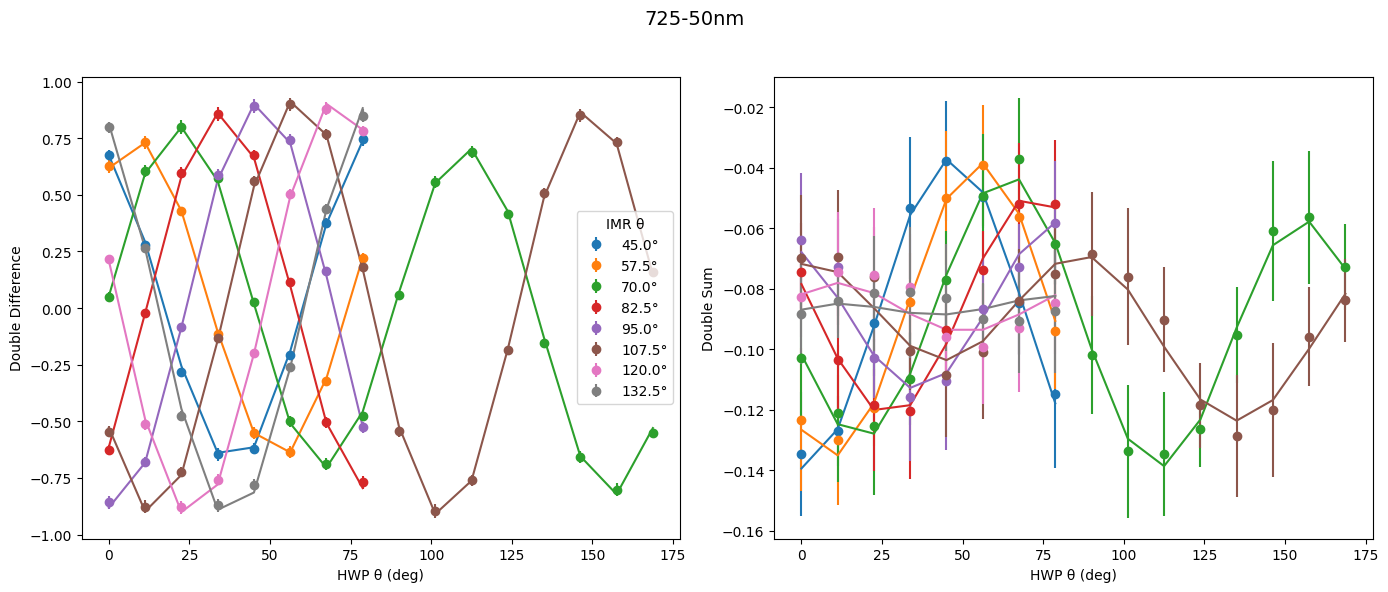

After p0: {'dichroic': {'phi': -0.03540705960979241, 'epsilon': 0.3671422066759701, 'theta': -44.576698723182744}, 'flc': {'phi': 3.219372443036501, 'delta_theta': 4.999999999465667}, 'optics': {'phi': 0.3379984584276122, 'epsilon': 0.0030899842894654495, 'theta': -48.51772262766045}, 'image_rotator': {'phi': 2.7531817062440473}, 'hwp': {'phi': 2.9971509689498417, 'delta_theta': 1.3880065534913446}, 'lp': {'theta': 4.5327416161562235}}
Before p0: {'dichroic': {'phi': -0.03540705960979241, 'epsilon': 0.3671422066759701, 'theta': -44.576698723182744}, 'flc': {'phi': 3.219372443036501, 'delta_theta': 4.999999999465667}, 'optics': {'phi': 0.3379984584276122, 'epsilon': 0.0030899842894654495, 'theta': -48.51772262766045}, 'image_rotator': {'phi': 2.7531817062440473}, 'hwp': {'phi': 2.9971509689498417, 'delta_theta': 1.3880065534913446}, 'lp': {'theta': 4.5327416161562235}}
Iteration #: 9
logl_value: 19.91615463587639
Best Fit Parameters: [-3.54072246e-02  3.67142266e-01 -4.45766875e+01  3.2

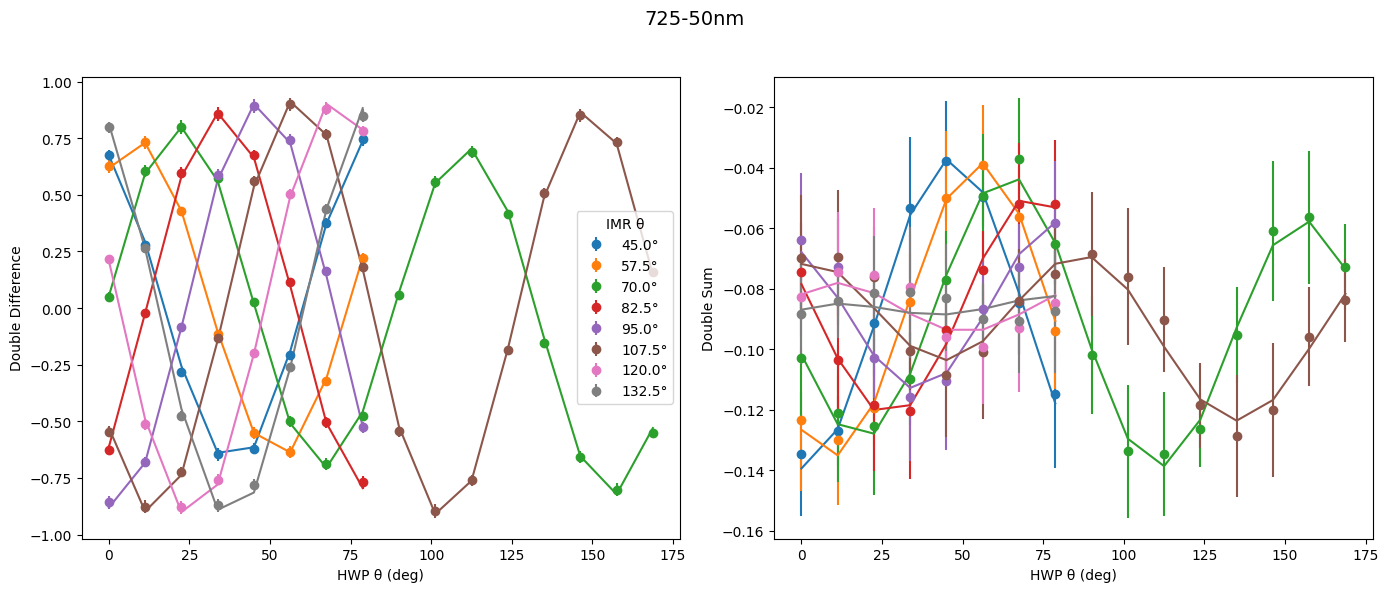

After p0: {'dichroic': {'phi': -0.03540722461193446, 'epsilon': 0.3671422660537689, 'theta': -44.57668747626756}, 'flc': {'phi': 3.2193721153563324, 'delta_theta': 4.999999999361114}, 'optics': {'phi': 0.3379978291710753, 'epsilon': 0.003090056191198479, 'theta': -48.51766977371967}, 'image_rotator': {'phi': 2.753181844526619}, 'hwp': {'phi': 2.997150947178034, 'delta_theta': 1.38803145465572}, 'lp': {'theta': 4.532794124062878}}
Before p0: {'dichroic': {'phi': -0.03540722461193446, 'epsilon': 0.3671422660537689, 'theta': -44.57668747626756}, 'flc': {'phi': 3.2193721153563324, 'delta_theta': 4.999999999361114}, 'optics': {'phi': 0.3379978291710753, 'epsilon': 0.003090056191198479, 'theta': -48.51766977371967}, 'image_rotator': {'phi': 2.753181844526619}, 'hwp': {'phi': 2.997150947178034, 'delta_theta': 1.38803145465572}, 'lp': {'theta': 4.532794124062878}}
Iteration #: 10
logl_value: 19.916154632980145
Best Fit Parameters: [-3.54082885e-02  3.67142007e-01 -4.45766921e+01  3.21937054e+0

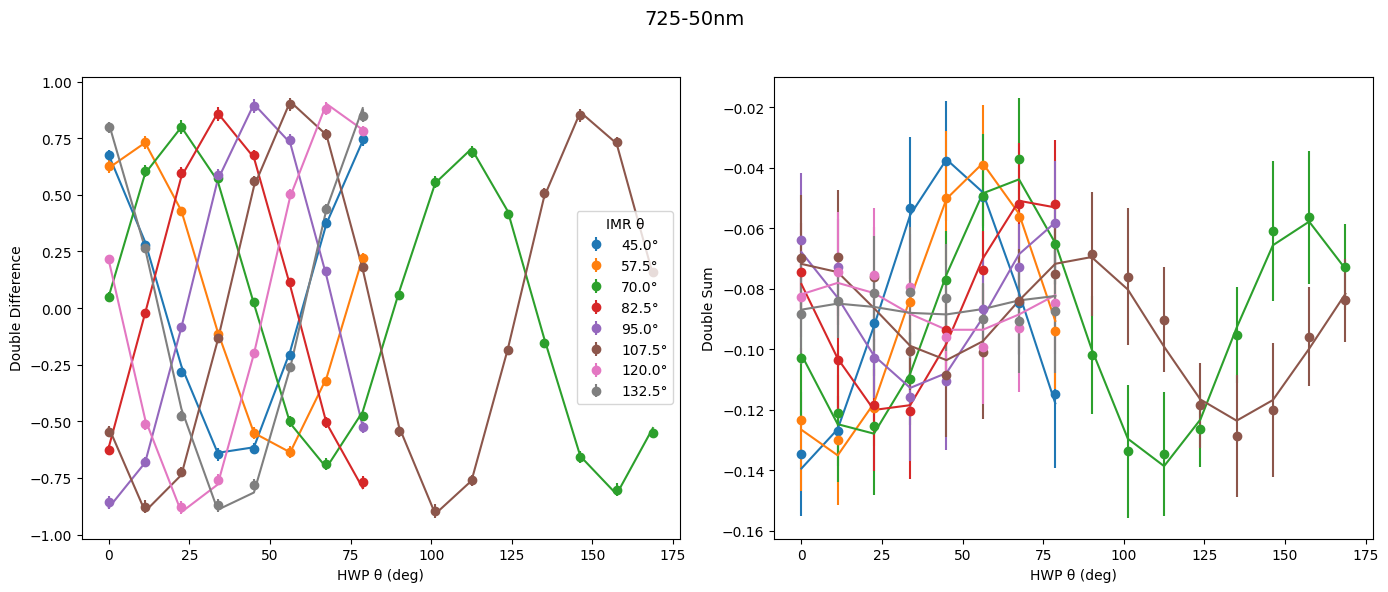

After p0: {'dichroic': {'phi': -0.035408288494618356, 'epsilon': 0.367142007287265, 'theta': -44.57669205918424}, 'flc': {'phi': 3.2193705352482915, 'delta_theta': 4.999999999047095}, 'optics': {'phi': 0.3379972128550551, 'epsilon': 0.003090142263658568, 'theta': -48.517646848138966}, 'image_rotator': {'phi': 2.7531818402481356}, 'hwp': {'phi': 2.9971512331238372, 'delta_theta': 1.3880340203376083}, 'lp': {'theta': 4.532799070042778}}
Before p0: {'dichroic': {'phi': -0.035408288494618356, 'epsilon': 0.367142007287265, 'theta': -44.57669205918424}, 'flc': {'phi': 3.2193705352482915, 'delta_theta': 4.999999999047095}, 'optics': {'phi': 0.3379972128550551, 'epsilon': 0.003090142263658568, 'theta': -48.517646848138966}, 'image_rotator': {'phi': 2.7531818402481356}, 'hwp': {'phi': 2.9971512331238372, 'delta_theta': 1.3880340203376083}, 'lp': {'theta': 4.532799070042778}}
Iteration #: 11
logl_value: 19.91615463035787
Best Fit Parameters: [-3.54076559e-02  3.67141510e-01 -4.45766936e+01  3.21

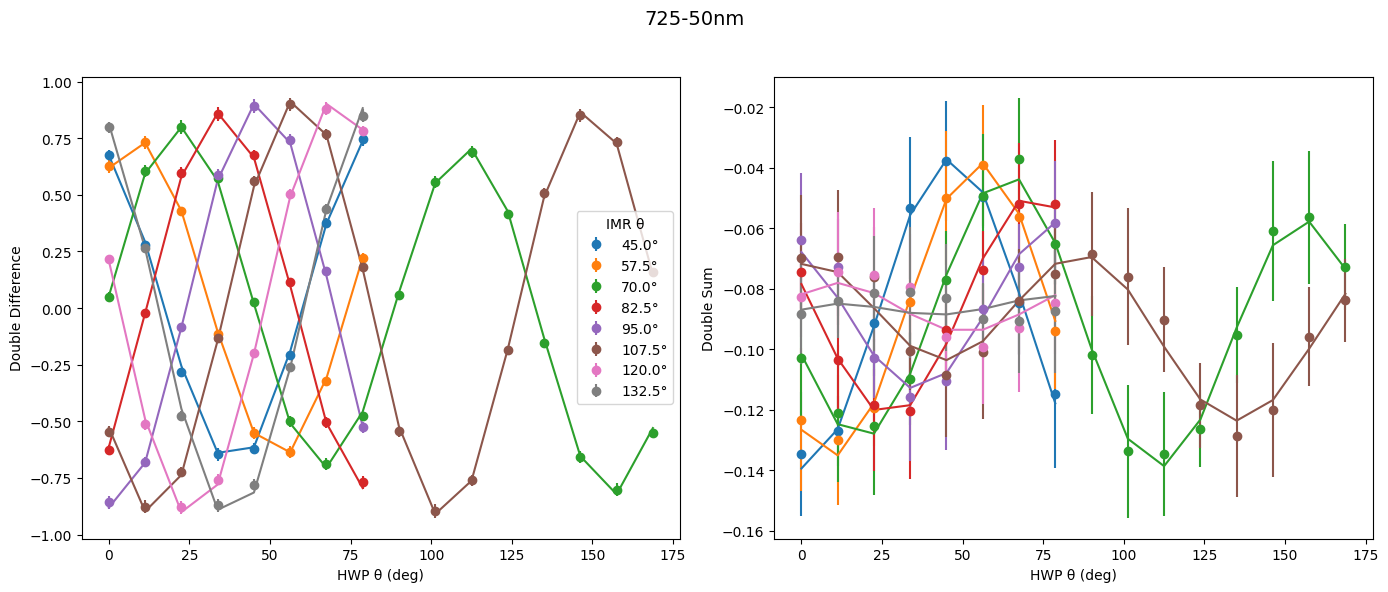

After p0: {'dichroic': {'phi': -0.03540765591134209, 'epsilon': 0.3671415095424222, 'theta': -44.5766935504094}, 'flc': {'phi': 3.219371730957495, 'delta_theta': 4.9999999984761105}, 'optics': {'phi': 0.33799860868228204, 'epsilon': 0.0030900959171195168, 'theta': -48.51759945098479}, 'image_rotator': {'phi': 2.7531825196434605}, 'hwp': {'phi': 2.9971514502037824, 'delta_theta': 1.3880554136993561}, 'lp': {'theta': 4.53283651011585}}
Before p0: {'dichroic': {'phi': -0.03540765591134209, 'epsilon': 0.3671415095424222, 'theta': -44.5766935504094}, 'flc': {'phi': 3.219371730957495, 'delta_theta': 4.9999999984761105}, 'optics': {'phi': 0.33799860868228204, 'epsilon': 0.0030900959171195168, 'theta': -48.51759945098479}, 'image_rotator': {'phi': 2.7531825196434605}, 'hwp': {'phi': 2.9971514502037824, 'delta_theta': 1.3880554136993561}, 'lp': {'theta': 4.53283651011585}}
Iteration #: 12
logl_value: 19.916154626053416
Best Fit Parameters: [-3.54072384e-02  3.67142078e-01 -4.45766925e+01  3.219

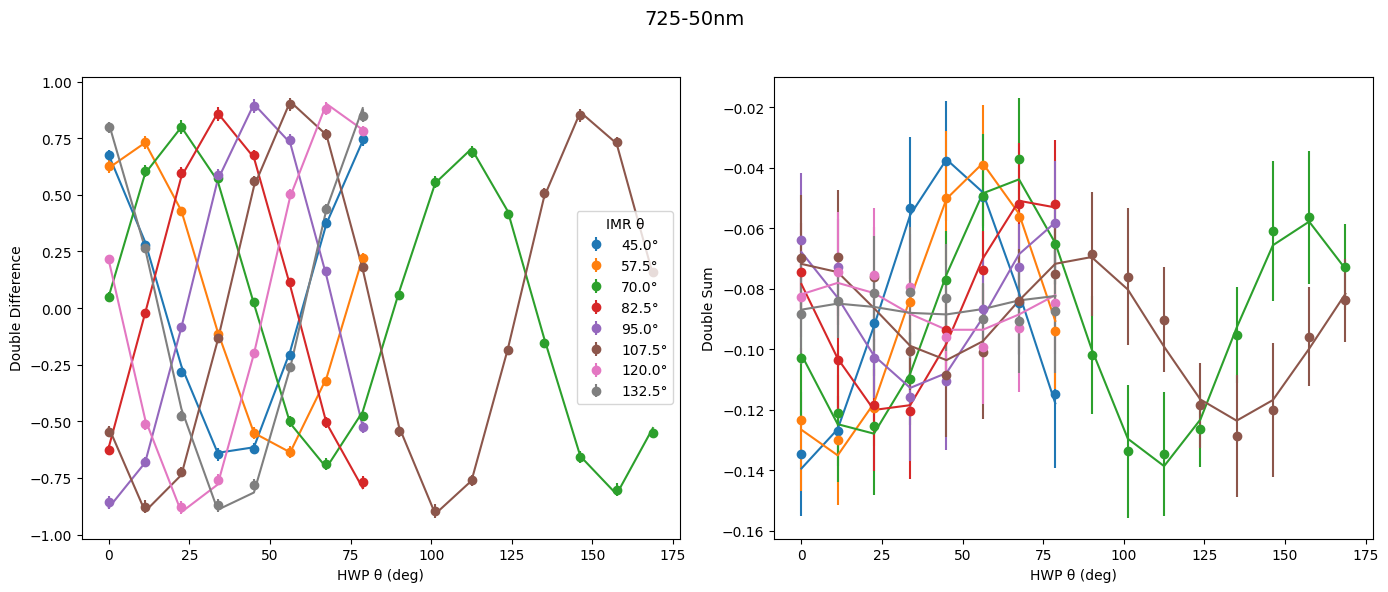

After p0: {'dichroic': {'phi': -0.03540723843438347, 'epsilon': 0.3671420783517608, 'theta': -44.57669246708937}, 'flc': {'phi': 3.219372252852101, 'delta_theta': 4.999999997312573}, 'optics': {'phi': 0.3379980715556904, 'epsilon': 0.003090266607428392, 'theta': -48.51773887044277}, 'image_rotator': {'phi': 2.7531810131588093}, 'hwp': {'phi': 2.997151278890313, 'delta_theta': 1.3880794728687822}, 'lp': {'theta': 4.532892477428982}}
Before p0: {'dichroic': {'phi': -0.03540723843438347, 'epsilon': 0.3671420783517608, 'theta': -44.57669246708937}, 'flc': {'phi': 3.219372252852101, 'delta_theta': 4.999999997312573}, 'optics': {'phi': 0.3379980715556904, 'epsilon': 0.003090266607428392, 'theta': -48.51773887044277}, 'image_rotator': {'phi': 2.7531810131588093}, 'hwp': {'phi': 2.997151278890313, 'delta_theta': 1.3880794728687822}, 'lp': {'theta': 4.532892477428982}}
Iteration #: 13
logl_value: 19.916154626053416
Best Fit Parameters: [-3.54072384e-02  3.67142078e-01 -4.45766925e+01  3.2193722

In [7]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds = [ 
    (-2 * np.pi, 2 * np.pi), # dichroic_retardance
    (0, 1), # dichroic_diattenuation
    (-90, 90), # dichroic_rotation_angle 
    (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),  # delta_FLC
    (-5, 5),  # rot_FLC
    (-np.pi, np.pi),  # delta_opts
    (0, 0.1),  # epsilon_opts
    (-90, 90),  # rot_opts
    ((delta_derot - delta_derot * 0.1) * 2 * np.pi, (delta_derot + delta_derot * 0.1) * 2 * np.pi),  # delta_derot
    ((delta_HWP - delta_HWP * 0.1) * 2 * np.pi, 0.5 * 2 * np.pi),  # delta_HWP
    (-5, 5),  # offset_HWP
    (-5, 5),  # theta_pol
]
# Counters for iterative fitting
iteration = 1
previous_logl_value = np.inf
new_logl_value = None
best_result = None

while True:
    print("Before p0: " + str(p0))
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    new_logl_value = float(new_logl_value)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    if new_logl_value >= previous_logl_value:
        print("Stopping: logl did not improve over the previous iteration.")
        if best_result is not None:
            result = best_result
        break

    previous_logl_value = new_logl_value
    best_result = result

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    # Updating p0 for next time
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_no_IMR_offset_iterate_on_any_improvement_with_dichroic_best_fit_old_fit_values.txt"
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)

    iteration += 1

# Step 6: Plot model with best fit

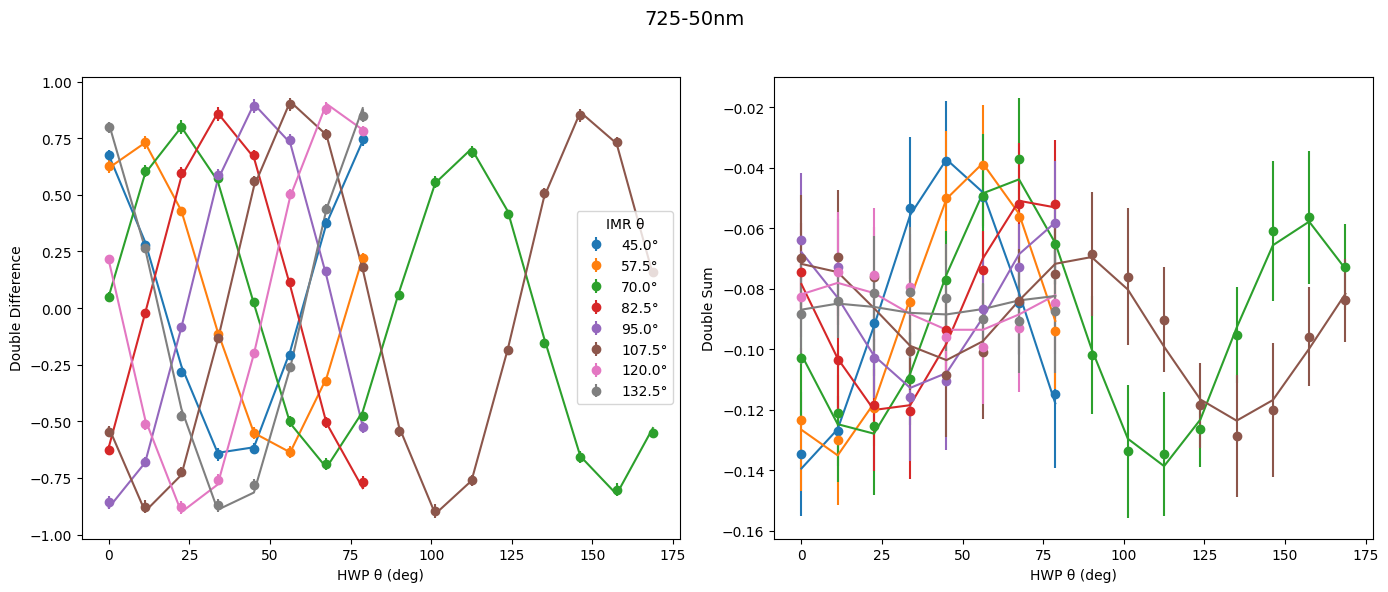

In [8]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
dichroic_phi = 0 # (waves)
dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)